In [1]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_gas
importlib.reload(two_component_gas)
from two_component_gas import TwoComponentGas


In [2]:
gas = TwoComponentGas(
    element="87Rb",
    N_particles=(5e4, 5e4),
    N_grid=32,
    grid_size=(20e-6, 20e-6, 3e-6),
)

sigma = 3e-6 / gas.adim_length

psi1 = torch.exp(-(gas.X**2 + gas.Y**2 + gas.Z**2 * 100) / (2 * sigma**2))
psi2 = torch.exp(-(gas.X**2 + gas.Y**2 + gas.Z**2 * 100) / (2 * sigma**2))

gas.psi = torch.stack([psi1, psi2], dim=0)

print(gas.psi.shape)
print(gas.psik.shape)

print(torch.sum(torch.abs(gas.psi[0]) ** 2) * gas.dx * gas.dy * gas.dz)
print(torch.sum(torch.abs(gas.psi[1]) ** 2) * gas.dx * gas.dy * gas.dz)

torch.Size([2, 32, 32, 32])
torch.Size([2, 64, 64, 64])
tensor(1.0000, dtype=torch.float64)
tensor(1.0000, dtype=torch.float64)


In [12]:
import potentials3D
importlib.reload(potentials3D)
from potentials3D import TwoComponentContact, Trap3D, TwoComponentDipoleDipole3D

import energy_callback
importlib.reload(energy_callback)
from energy_callback import TwoComponentDipolarEnergyMonitor3D

# For magnetic 87Rb, a_dd is tiny, about 0.7 Bohr radii.
# For testing the code, you may temporarily use a larger value,
# but do not confuse a_dd with the contact scattering length a_s.

dipole = TwoComponentDipoleDipole3D(
    a_dd11_bohr=0.7,
    a_dd22_bohr=0.7,
    a_dd12_bohr=0.7,
    polarization=(0.0, 0.0, 1.0),
)

a = 100
contact = TwoComponentContact(a_s = a)
trap = Trap3D(omegax = 400, omegay = 400, omegaz = 4000)

# Manually initialize contact before reading _g1/_g2
contact.set_gas(gas)
contact.on_propagation_begin()

energy_cb = TwoComponentDipolarEnergyMonitor3D(
    dipole=dipole,
    linear_potentials=[trap],
    physical_energy=True,
    per_particle=True,
    compute_every=100,
    print_every=1000,
    use_spectral_kinetic=True,
)

In [13]:
dipole.set_gas(gas)
dipole.on_propagation_begin()

print("gdd11 =", dipole._gdd11)
print("gdd22 =", dipole._gdd22)
print("gdd12_on_1 =", dipole._gdd12_on_1)
print("gdd12_on_2 =", dipole._gdd12_on_2)

gdd11 = 23.27442933508002
gdd22 = 23.27442933508002
gdd12_on_1 = 23.27442933508002
gdd12_on_2 = 23.27442933508002


In [16]:
gas.ground_state(
    potentials=[trap, dipole],
    time_step=-1e-7j,
    N_iterations=50_000,
    callbacks=[energy_cb],
)

Ground state:   0%|          | 0/50000 [00:00<?]

epoch        0 | E/N = 3.739716914710e+01 | Ekin = 8.826373e+00 | Epot = 2.171284e+01 | Edd = 6.857956e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = nan
epoch     1000 | E/N = 3.531813288317e+01 | Ekin = 8.081012e+00 | Epot = 1.941691e+01 | Edd = 7.820211e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = 2.165e-02
epoch     2000 | E/N = 3.451978814700e+01 | Ekin = 7.761888e+00 | Epot = 1.880163e+01 | Edd = 7.956272e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = 1.385e-02
epoch     3000 | E/N = 3.416261467862e+01 | Ekin = 7.633543e+00 | Epot = 1.866002e+01 | Edd = 7.869047e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = 9.644e-03
epoch     4000 | E/N = 3.397662783386e+01 | Ekin = 7.566581e+00 | Epot = 1.864700e+01 | Edd = 7.763050e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = 7.271e-03
epoch     5000 | E/N = 3.385562138580e+01 | Ekin = 7.511892e+00 | Epot = 1.864904e+01 | Edd = 7.694686e+00 | N1 = 1.000000e+00 | N2 = 1.000000e+00 | dpsi = 6.303e-03
epoch     

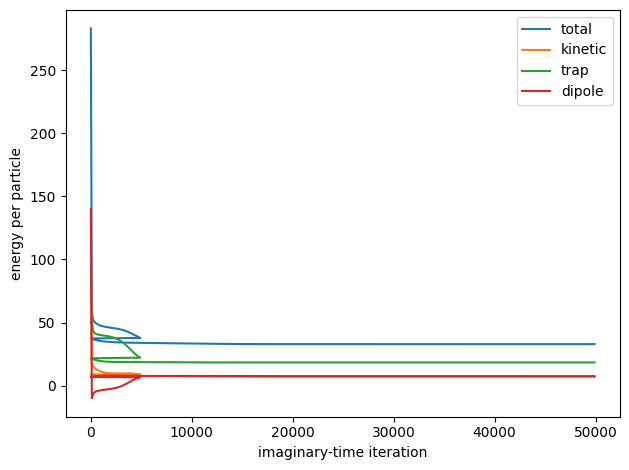

In [17]:
import matplotlib.pyplot as plt

plt.plot(energy_cb.epochs, energy_cb.energy_total, label="total")
plt.plot(energy_cb.epochs, energy_cb.energy_kinetic, label="kinetic")
plt.plot(energy_cb.epochs, energy_cb.energy_potential, label="trap")
plt.plot(energy_cb.epochs, energy_cb.energy_dipole, label="dipole")
plt.xlabel("imaginary-time iteration")
plt.ylabel("energy per particle")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

E = np.array(energy_cb.energy_total)

relative_energy_change = abs(E[-1] - E[-10]) / abs(E[-1])
latest_wavefunction_change = energy_cb.relative_change[-1]

print("relative energy change:", relative_energy_change)
print("latest wavefunction change:", latest_wavefunction_change)

relative energy change: 9.593560172309974e-07
latest wavefunction change: 0.00011028189953037115
